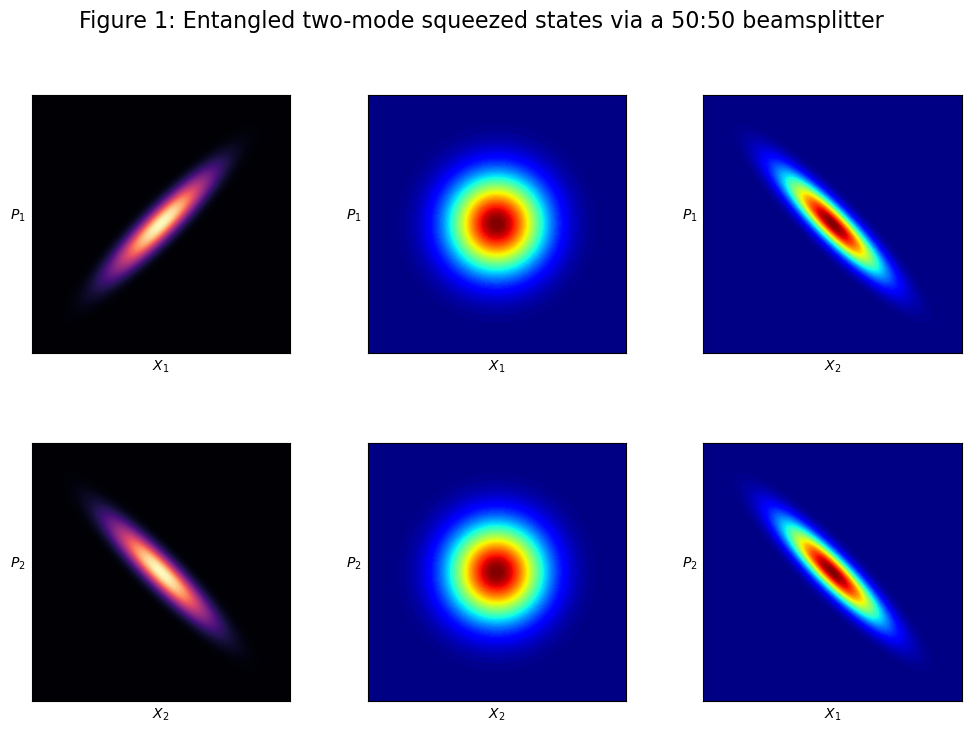

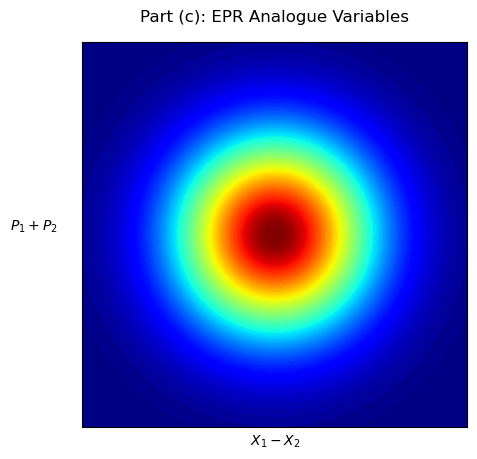

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# global parameter
N = 15        
r = 0.8       # Squeezing parameter

# ------------------------------------------------------------------------
a1 = tensor(destroy(N), qeye(N))
a2 = tensor(qeye(N), destroy(N))
x1 = (a1 + a1.dag()) / np.sqrt(2)
p1 = -1j * (a1 - a1.dag()) / np.sqrt(2)
x2 = (a2 + a2.dag()) / np.sqrt(2)
p2 = -1j * (a2 - a2.dag()) / np.sqrt(2)

# ------------------------------------------------------------------------
S1_op = tensor(squeeze(N, -1j * r), qeye(N))
S2_op = tensor(qeye(N), squeeze(N, 1j * r))
vac = tensor(basis(N, 0), basis(N, 0))
psi_in = S1_op * S2_op * vac

theta_bs = np.pi / 4
BS_op = (theta_bs * (a1.dag() * a2 - a1 * a2.dag())).expm()
psi_out = BS_op * psi_in

# ------------------------------------------------------------------------
def get_covariance(opA, opB, state):
    return (0.5 * expect(opA*opB + opB*opA, state)
            - expect(opA, state) * expect(opB, state))

def plot_phase_space(opA, opB, state, ax, xlabel, ylabel, cmap='jet'):
    V_AA = get_covariance(opA, opA, state).real
    V_BB = get_covariance(opB, opB, state).real
    V_AB = get_covariance(opA, opB, state).real
    V = np.array([[V_AA, V_AB], [V_AB, V_BB]])

    limit = 4.5
    grid = np.linspace(-limit, limit, 100)
    X, Y = np.meshgrid(grid, grid)

    invV = np.linalg.inv(V)
    pos  = np.stack([X, Y], axis=-1)
    Z    = np.einsum('...i,ij,...j->...', pos, invV, pos)
    Z    = np.exp(-0.5 * Z)

    ax.contourf(X, Y, Z, 100, cmap=cmap)
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel(ylabel, fontweight='bold', rotation=0, labelpad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

# ------------------------------------------------------------------------
# (a) & (b)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
plt.subplots_adjust(wspace=0.3, hspace=0.3)

plot_phase_space(x1, p1, psi_in,  axes[0, 0], '$X_1$', '$P_1$', cmap='magma')
plot_phase_space(x2, p2, psi_in,  axes[1, 0], '$X_2$', '$P_2$', cmap='magma')
plot_phase_space(x1, p1, psi_out, axes[0, 1], '$X_1$', '$P_1$', cmap='jet')
plot_phase_space(x2, p2, psi_out, axes[1, 1], '$X_2$', '$P_2$', cmap='jet')
plot_phase_space(x2, p1, psi_out, axes[0, 2], '$X_2$', '$P_1$', cmap='jet')
plot_phase_space(x1, p2, psi_out, axes[1, 2], '$X_1$', '$P_2$', cmap='jet')

fig.suptitle('Figure 1: Entangled two-mode squeezed states via a 50:50 beamsplitter', fontsize=16)
plt.show()

# ------------------------------------------------------------------------
# (c)
fig_c, ax_c = plt.subplots(1, 1, figsize=(6, 5))
fig_c.subplots_adjust(left=0.18)

u = x1 - x2
v = p1 + p2
plot_phase_space(u, v, psi_out, ax_c, '$X_1 - X_2$', '$P_1 + P_2$', cmap='jet')

ax_c.set_ylabel('$P_1 + P_2$', fontweight='bold', rotation=0, labelpad=35)
ax_c.set_title('Part (c): EPR Analogue Variables', pad=15)

plt.show()